In [61]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [62]:
df=pd.read_excel("Final Project Data (Titanic)(1).xlsx")
df.head(5)
#You can omit the number five because five will appear automatically.


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [63]:
df.info()
#before

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [64]:
df[["Name", "Ticket", "Cabin"]] = df[["Name", "Ticket", "Cabin"]].astype("string")
df[["Sex", "Embarked", "Pclass"]]=df[["Sex", "Embarked", "Pclass"]].astype("category")
df.info()
#after
# I changed the type of columns in the data because some columns were of the wrong type and not useful for the analysis. For instance, columns such as Name, Ticket, and Cabin were of type object, and object is a general type that does not specify that it is a word. Therefore, I changed it to a string type to enable the program to recognize it as a word. Similarly, columns such as Sex, Embarked, and Pclass were changed to category because they contain fixed and recurring values such as Male/Female, Port, and Degree. This makes the work easy and organized.


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   PassengerId  891 non-null    int64   
 1   Survived     891 non-null    int64   
 2   Pclass       891 non-null    category
 3   Name         891 non-null    string  
 4   Sex          891 non-null    category
 5   Age          714 non-null    float64 
 6   SibSp        891 non-null    int64   
 7   Parch        891 non-null    int64   
 8   Ticket       891 non-null    string  
 9   Fare         891 non-null    float64 
 10  Cabin        204 non-null    string  
 11  Embarked     889 non-null    category
dtypes: category(3), float64(2), int64(4), string(3)
memory usage: 65.8 KB


In [65]:
df.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


In [66]:
df.isnull().sum()
#To quickly count the number of empty values in each column, I used the command `df.isnull().sum()`. The function `isnull()` sets empty values to `True` and filled values to `False`, and the `sum()` function sums the number of `True` values in each column, giving me the number of missing values directly.

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [67]:
df.drop(columns=["Cabin"], inplace=True, errors='ignore')
#I removed the Cabin column by using the following code: `df.drop(columns=["Cabin"], inplace=True, errors="ignore")`. The reason I removed this column was that it contained missing values, and I found it not useful for my analysis. The `columns=["Cabin"]` parameter was used to specify that I was dropping this column. The `inplace=True` parameter was used because I wanted to make the changes directly to the original table instead of creating a new one. The `errors="ignore"` parameter was used because the Cabin column may be missing in the data. This ensures that Python does not throw an error if the column is missing; instead, it runs normally. I used `df.head()` to preview the first five rows of the table to ensure that I had successfully dropped the column and that the table was in the desired form before moving on to the next steps.

In [68]:

df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
df["Age"] = df["Age"].fillna(df["Age"].median())
#I used the code `df["Age"] = pd.to_numeric(df["Age"], errors="coerce")` to ensure that my column was 100% numeric. If there was anything in there that could not be made into a number, like a space, symbol, or text, it would simply change it to NaN, rather than stopping my code and giving me an error. Right after that, I used `df["Age"] = df["Age"].fillna(df["Age"].median())` to deal with my missing values. I used the median to replace my missing values because it is not as influenced by outliers, giving me a replacement that is completely logical, as it is in the middle of all of my ages.


In [69]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])
#In the Embarked column, I only had two missing values, so I decided against deleting the rows and losing data unnecessarily. Instead, I filled in the missing values ​​using `df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])`. This is because the column is categorical (its values ​​are limited and repetitive), and the mode is the appropriate setting in this case. This way, I maintain the existing inventory and ensure the column is complete and ready for analysis without significantly altering the results. After confirming that the order number was 0, I confidently proceeded with the remaining steps.

In [70]:
df.isnull().sum()
#use df.isnull().sum() to check and compare

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [71]:
df.duplicated().sum()
#To ensure that the data didn't have duplicate values that might interfere with the results, I used the `df.duplicated().sum()` function. After using this function, the data was observed to have no duplicate values in any of the data columns, and the result obtained was a perfect zero. This shows that the data is clean and doesn't have to be deleted because of duplication. This step is significant because, before undertaking the cleaning and analysis processes, the data has to be checked for duplicates. Since the function returned zero, the data is considered duplicate-free and can be worked on.


np.int64(0)

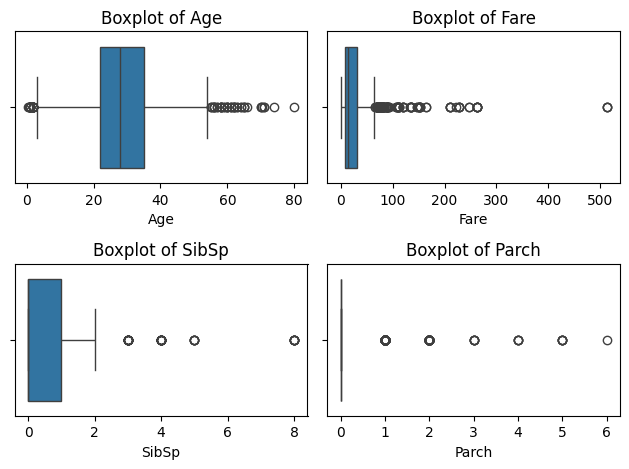

In [72]:
numeric_cols = ["Age", "Fare", "SibSp", "Parch"]


for i, col in enumerate(numeric_cols, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
plt.tight_layout()
plt.show()


In [73]:
df["Fare"]=df["Fare"].clip(upper=df["Fare"].quantile(0.99))

In [74]:
def clean_data(df):
    # -------------------------
    # 1. Fix column dtypes
    # -------------------------
    df[["Name", "Ticket", "Cabin"]] = df[["Name", "Ticket", "Cabin"]].astype("string")
    df[["Sex", "Embarked", "Pclass"]] = df[["Sex", "Embarked", "Pclass"]].astype("category")

    # -------------------------
    # 2. Drop Cabin column
    df.drop(columns=["Cabin"], inplace=True, errors='ignore')

    # -------------------------
    # 3. Clean Age column
    # -------------------------
    df["Age"] = pd.to_numeric(df["Age"], errors="coerce")
    df["Age"] = df["Age"].fillna(df["Age"].median())

    # -------------------------
    # 4. Clean Embarked column
    # -------------------------
    df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

    # -------------------------
    # 5. Remove duplicates if any
    # -------------------------
    df = df.drop_duplicates()

    # -------------------------
    # 6. Cap Outliers (Fare)
    #    — limit at 99th percentile
    # -------------------------
    p99 = df["Fare"].quantile(0.99)
    df["Fare"] = df["Fare"].clip(upper=p99)
    return df

In [75]:
df.to_excel("Data (Titanic) Cleaned.xlsx", index=False)